# 3 - SMS Spam Detection - NLP

<img src='https://www.everlytic.com/wp-content/uploads/2022/09/Everlytic-Spam-Blog-Image-1.jpg'>

Bu çalışmada SMS mesajlarının spam mı normal mi olduğunu tahmin eden bir NLP modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Metin ön işleme
5. TF-IDF ile sayısallaştırma
6. Classification modelleri kurma
7. En iyi modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

## 1. Veriyi Yükleme

In [2]:
# Bu projede Kaggle'dan indirilen SMS spam datasetini Colab üzerinden zip dosyası olarak açıp kullanacağım.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/SMS Spam Detection Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'spam_sms.csv', 'drive', 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [5]:
# Bu bölümde csv dosyasını okuyup veri setinin yapısını inceleyeceğim.

In [6]:
file_path = '/content/spam_sms.csv'

df = pd.read_csv(file_path)
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.shape

(5572, 2)

In [8]:
df.columns.tolist()

['v1', 'v2']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


## 3. Veri Temizleme

In [10]:
# Bu bölümde sütun isimlerini anlamlı hale getirip boş verileri temizleyeceğim.

In [11]:
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['message', 'label']].dropna().copy()
df.head()

,message,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [12]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


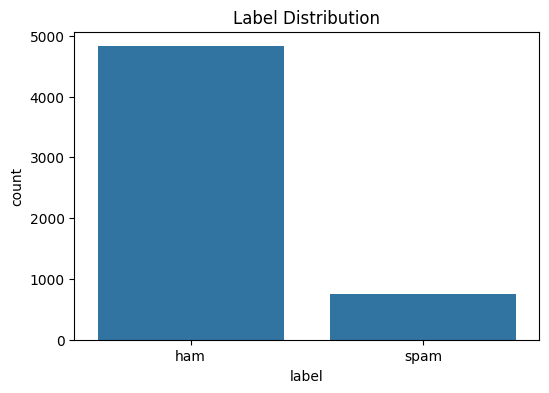

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.show()

## 4. Metin Ön İşleme

In [14]:
# Bu bölümde SMS metinlerini küçük harfe çevirip link, noktalama ve gereksiz karakterleri temizleyeceğim.

In [15]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## 5. TF-IDF ile Sayısallaştırma

In [17]:
x = df['clean_message']
y = df['label']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=3000)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

x_train_tfidf.shape, x_test_tfidf.shape

((4457, 3000), (1115, 3000))

## 6. Classification Modelleri Kurma

In [18]:
# Bu bölümde birkaç farklı classification modeli kurup sonuçları karşılaştıracağım.

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(x_train_tfidf, y_train)
    y_pred = model.predict(x_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append([name, accuracy, f1])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,F1
2,Random Forest,0.973094,0.971794
0,Logistic Regression,0.972197,0.970904
1,Multinomial Naive Bayes,0.965919,0.963890


## 7. En İyi Modeli Değerlendirme

In [21]:
best_model_name = results_df.sort_values(by='F1', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test_tfidf)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test, best_pred))
print('F1 Score:', f1_score(y_test, best_pred, average='weighted'))
print(classification_report(y_test, best_pred))

Best Model: Random Forest
Accuracy: 0.9730941704035875
F1 Score: 0.9717939491664156
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



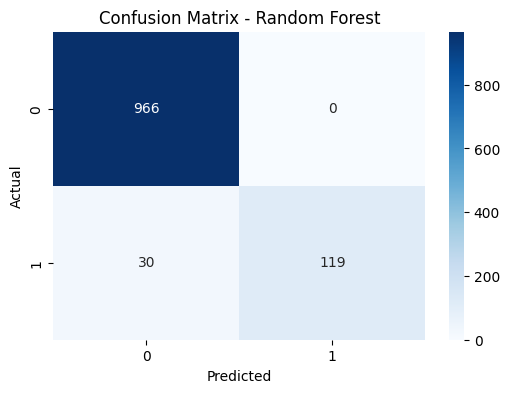

In [22]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [24]:
sample_text = x_test.iloc[0]
sample_vector = vectorizer.transform([sample_text])
sample_prediction = best_model.predict(sample_vector)[0]

print('Mesaj:', sample_text)
print('Tahmin edilen sınıf:', sample_prediction)
print('Gerçek sınıf:', y_test.iloc[0])

Mesaj: oh right ok ill make sure that i do loads of work during the day got a really nasty cough today and is dry n shot so that should really help it
Tahmin edilen sınıf: ham
Gerçek sınıf: ham


## 9. Sonuç

Bu projede SMS mesajlarının spam mı normal mi olduğunu tahmin etmek için NLP tabanlı bir classification modeli kullanıldı. Elde edilen sonuçlara göre en başarılı model 0.9731 accuracy ve 0.9718 F1 score değeri ile Random Forest oldu.
